In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Welcome\Downloads\diabetes.csv")
print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
feature_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target_col = ['Outcome']

In [7]:
missing = df.isnull().sum().sort_values(ascending = False)
missing = missing[missing>0]
print('Missing columns :',missing)

Missing columns : Series([], dtype: int64)


In [9]:
df = df.fillna(df.median(numeric_only = True))
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [13]:
feature_cols_std = ( ( df[feature_cols] - df[feature_cols].mean() ) / (df[feature_cols].std() ) )
print(feature_cols_std.head())

    Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0  0.847771       0.149543       0.906679 -0.692439  0.203880   
1 -1.122665      -0.160441       0.530556 -0.692439 -0.683976   
2  1.942458      -0.263769      -1.287373 -0.692439 -1.102537   
3 -0.997558      -0.160441       0.154433  0.123221 -0.493721   
4  0.503727      -1.503707       0.906679  0.765337  1.408828   

   DiabetesPedigreeFunction       Age  
0                  0.468187  1.425067  
1                 -0.364823 -0.190548  
2                  0.604004 -0.105515  
3                 -0.920163 -1.040871  
4                  5.481337 -0.020483  


In [23]:
X = feature_cols_std
y = df['Outcome']
print('Class ratio',y.value_counts())
print('Imbalance ratio :', (y.value_counts().max() / y.value_counts().min() ))

Class ratio Outcome
0    500
1    268
Name: count, dtype: int64
Imbalance ratio : 1.8656716417910448


In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)

In [44]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
classes = np.unique(y_train)
class_weight = compute_class_weight(class_weight = 'balanced',classes = classes,y = y_train)
class_weight_dict = dict(zip(classes,class_weight))

In [70]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,confusion_matrix, classification_report,f1_score)

logreg_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(max_iter = 1000,random_state = 42,class_weight = class_weight_dict,penalty = 'l2',C = 100))
])

logreg_pipe.fit(X_train,y_train)

y_pred_train_logreg = logreg_pipe.predict(X_train)
y_pred_test_logreg = logreg_pipe.predict(X_test)

print('Overfit check')
print('Training accuracy :',accuracy_score(y_train,y_pred_train_logreg))
print('Testing accuracy :',accuracy_score(y_test,y_pred_test_logreg))

print('Evaluation metrics')
print('Accuracy :',accuracy_score(y_test,y_pred_test_logreg))
print('Balanced accuracy :',balanced_accuracy_score(y_test,y_pred_test_logreg))
cm_logreg = confusion_matrix(y_test,y_pred_test_logreg)
tn_logreg,fp_logreg,fn_logreg,tp_logreg = cm_logreg.ravel()
sensitivity_logreg = tp_logreg / (tp_logreg + fn_logreg)
specificity_logreg = tn_logreg / (tn_logreg + fp_logreg)
print('Sensitivity :',sensitivity_logreg)
print('Specificity :',specificity_logreg)
print('f1 score :',f1_score(y_test,y_pred_test_logreg))
print('Confusion Matrix \n')
print(confusion_matrix(y_test,y_pred_test_logreg))

Overfit check
Training accuracy : 0.758957654723127
Testing accuracy : 0.7337662337662337
Evaluation metrics
Accuracy : 0.7337662337662337
Balanced accuracy : 0.7225925925925927
Sensitivity : 0.6851851851851852
Specificity : 0.76
f1 score : 0.6434782608695652
Confusion Matrix 

[[76 24]
 [17 37]]


In [100]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler',StandardScaler()),
    ('model',RandomForestClassifier(n_estimators = 300, max_depth=4,min_samples_split=2,min_samples_leaf=2,class_weight = 'balanced',random_state = 42))
])
rf_pipe.fit(X_train,y_train)

y_pred_train_rf = rf_pipe.predict(X_train)
y_pred_test_rf = rf_pipe.predict(X_test)

print('Overfit check')
print('Training accuracy :',accuracy_score(y_train,y_pred_train_rf))
print('Testing accuracy :',accuracy_score(y_test,y_pred_test_rf))

print('Accuracy :',accuracy_score(y_test,y_pred_test_rf))
print('Balanced accuracy :',balanced_accuracy_score(y_test,y_pred_test_rf))
cm_rf = confusion_matrix(y_test,y_pred_test_rf)
tn_rf,fp_rf,fn_rf,tp_rf = cm_rf.ravel()
sensitivity_rf = tp_rf / (tp_rf + fn_rf)
specificity_rf = tn_rf / (tn_rf + fp_rf)
print('Sensitivity :',sensitivity_rf)
print('Specificity :',specificity_rf)
print('f1 score :',f1_score(y_test,y_pred_test_rf))
print('Confusion Matrix \n')
print(confusion_matrix(y_test,y_pred_test_rf))

Overfit check
Training accuracy : 0.8143322475570033
Testing accuracy : 0.7597402597402597
Accuracy : 0.7597402597402597
Balanced accuracy : 0.7553703703703704
Sensitivity : 0.7407407407407407
Specificity : 0.77
f1 score : 0.6837606837606838
Confusion Matrix 

[[77 23]
 [14 40]]


In [106]:
print(len(X_train))

614


In [108]:
print(df.shape)

(768, 9)


In [110]:
print(len(X_test))

154


In [126]:
#gradient boosting classifier
from sklearn.ensemble import GradientBoostingClassifier

gb_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler',StandardScaler()),
    ('model',GradientBoostingClassifier(n_estimators = 300,learning_rate = 0.0005,max_depth = 3,random_state = 42))
])

gb_pipe.fit(X_train,y_train)

y_pred_train_gb = gb_pipe.predict(X_train)
y_pred_test_gb = gb_pipe.predict(X_test)


print('Overfit check')
print('Training accuracy :',accuracy_score(y_train,y_pred_train_gb))
print('Testing accuracy :',accuracy_score(y_test,y_pred_test_gb))

print('Accuracy :',accuracy_score(y_test,y_pred_test_gb))
print('Balanced accuracy :',balanced_accuracy_score(y_test,y_pred_test_gb))
cm_gb = confusion_matrix(y_test,y_pred_test_gb)
tn_gb,fp_gb,fn_gb,tp_gb = cm_gb.ravel()
sensitivity_gb = tp_gb / (tp_gb + fn_gb)
specificity_gb = tn_gb / (tn_gb + fp_gb)
print('Sensitivity :',sensitivity_gb)
print('Specificity :',specificity_gb)
print('f1 score :',f1_score(y_test,y_pred_test_gb))
print('Confusion Matrix \n')
print(confusion_matrix(y_test,y_pred_test_gb))

Overfit check
Training accuracy : 0.6514657980456026
Testing accuracy : 0.6493506493506493
Accuracy : 0.6493506493506493
Balanced accuracy : 0.5
Sensitivity : 0.0
Specificity : 1.0
f1 score : 0.0
Confusion Matrix 

[[100   0]
 [ 54   0]]


In [136]:
#threshold tuning
y_prob_gb = gb_pipe.predict_proba(X_test)[:,1]
thresholds = np.arange(0.1,0.9,0.1)
results_gb = []

for thr in thresholds:
    y_pred_gb = (y_prob_gb >= thr).astype(int)
    cm = confusion_matrix(y_test,y_pred_gb)
    tn,fp,fn,tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    results_gb.append(
        {'threshold':thr,
        'accuracy' : accuracy_score(y_test,y_pred_gb),
        'balanced_accuracy ':balanced_accuracy_score(y_test,y_pred_gb),
        'sensitivity':sensitivity,
        'specificity':specificity,
        'tn':tn,
        'fp':fp,
        'fn':fn,
        'tp':tp}
    )

thresholds_df_gb = pd.DataFrame(results_gb)
print(thresholds_df_gb.head())

   threshold  accuracy  balanced_accuracy   sensitivity  specificity   tn  \
0        0.1  0.350649            0.500000     1.000000         0.00    0   
1        0.2  0.350649            0.500000     1.000000         0.00    0   
2        0.3  0.350649            0.500000     1.000000         0.00    0   
3        0.4  0.694805            0.598889     0.277778         0.92   92   
4        0.5  0.649351            0.500000     0.000000         1.00  100   

    fp  fn  tp  
0  100   0  54  
1  100   0  54  
2  100   0  54  
3    8  39  15  
4    0  54   0  


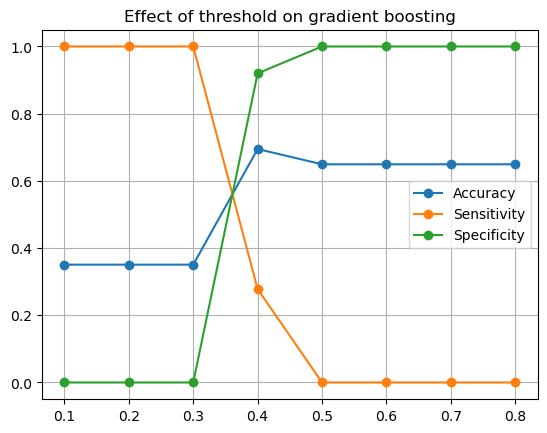

In [146]:
#plotting
import matplotlib.pyplot as plt

plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['accuracy'],marker = 'o',label = 'Accuracy')
#plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['balanced_accuracy'],marker = 'o',label = 'Balanced accuracy')
plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['sensitivity'],marker = 'o',label = 'Sensitivity')
plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['specificity'],marker = 'o',label = 'Specificity')
plt.title('Effect of threshold on gradient boosting')
plt.grid(True)
plt.legend()
plt.show()

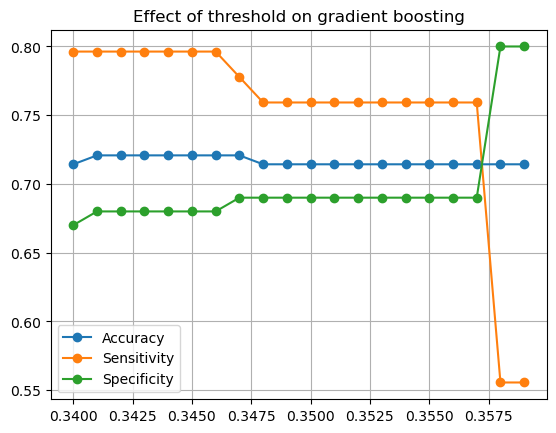

In [150]:
#threshold tuning
y_prob_gb = gb_pipe.predict_proba(X_test)[:,1]
thresholds = [0.34,0.341,0.342,0.343,0.344,0.345,0.346,0.347,0.348,0.349,0.35,0.351,0.352,0.353,0.354,0.355,0.356,0.357,0.358,0.359]
results_gb = []

for thr in thresholds:
    y_pred_gb = (y_prob_gb >= thr).astype(int)
    cm = confusion_matrix(y_test,y_pred_gb)
    tn,fp,fn,tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    results_gb.append(
        {'threshold':thr,
        'accuracy' : accuracy_score(y_test,y_pred_gb),
        'balanced_accuracy ':balanced_accuracy_score(y_test,y_pred_gb),
        'sensitivity':sensitivity,
        'specificity':specificity,
        'tn':tn,
        'fp':fp,
        'fn':fn,
        'tp':tp}
    )

thresholds_df_gb = pd.DataFrame(results_gb)
#print(thresholds_df_gb.head())
#plotting
import matplotlib.pyplot as plt

plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['accuracy'],marker = 'o',label = 'Accuracy')
#plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['balanced_accuracy'],marker = 'o',label = 'Balanced accuracy')
plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['sensitivity'],marker = 'o',label = 'Sensitivity')
plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['specificity'],marker = 'o',label = 'Specificity')
plt.title('Effect of threshold on gradient boosting')
plt.grid(True)
plt.legend()
plt.show()

In [152]:
#threshold = 0.3571
y_prob_gb = gb_pipe.predict_proba(X_test)[:,1]
y_pred_gb = (y_prob_gb >= 0.3571).astype(int)

print('Evaluation metrics - Threshold = 0.3571')
print('Accuracy :',accuracy_score(y_test,y_pred_gb))
print('Balanced accuracy :',balanced_accuracy_score(y_test,y_pred_gb))
cm_gb = confusion_matrix(y_test,y_pred_gb)
tn_gb, fp_gb, fn_gb, tp_gb = cm_gb.ravel()
sensitivity_gb = tp_gb / (tp_gb + fn_gb)
specificity_gb = tn_gb / (tn_gb + fp_gb)
print('Sensitivity :',sensitivity_gb)
print('Specificity :',specificity_gb)
print('f1 score :',f1_score(y_test,y_pred_gb))
print('Confusion Matrix \n')
print(confusion_matrix(y_test,y_pred_gb))

Evaluation metrics - Threshold = 0.3571
Accuracy : 0.7142857142857143
Balanced accuracy : 0.7246296296296296
Sensitivity : 0.7592592592592593
Specificity : 0.69
f1 score : 0.6507936507936508
Confusion Matrix 

[[69 31]
 [13 41]]


In [154]:
from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler',StandardScaler()),
    ('model',XGBClassifier(objective="binary:logistic",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.001,
        reg_lambda=95,
        random_state=42,
        eval_metric="logloss",
        class_weight = class_weight_dict))
])
xgb_pipe.fit(X_train,y_train)

y_pred_train_xgb = gb_pipe.predict(X_train)
y_pred_test_xgb = gb_pipe.predict(X_test)


print('Overfit check')
print('Training accuracy :',accuracy_score(y_train,y_pred_train_xgb))
print('Testing accuracy :',accuracy_score(y_test,y_pred_test_xgb))

print('Accuracy :',accuracy_score(y_test,y_pred_test_xgb))
print('Balanced accuracy :',balanced_accuracy_score(y_test,y_pred_test_xgb))
cm_xgb = confusion_matrix(y_test,y_pred_test_xgb)
tn_xgb,fp_xgb,fn_xgb,tp_xgb = cm_xgb.ravel()
sensitivity_xgb = tp_xgb / (tp_xgb + fn_xgb)
specificity_xgb = tn_xgb / (tn_xgb + fp_xgb)
print('Sensitivity :',sensitivity_xgb)
print('Specificity :',specificity_xgb)
print('f1 score :',f1_score(y_test,y_pred_test_xgb))
print('Confusion Matrix \n')
print(confusion_matrix(y_test,y_pred_test_xgb))

Overfit check
Training accuracy : 0.6514657980456026
Testing accuracy : 0.6493506493506493
Accuracy : 0.6493506493506493
Balanced accuracy : 0.5
Sensitivity : 0.0
Specificity : 1.0
f1 score : 0.0
Confusion Matrix 

[[100   0]
 [ 54   0]]


C:\Users\Welcome\anaconda3\envs\twin_health\lib\site-packages\xgboost\training.py:200: UserWarning: [12:12:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


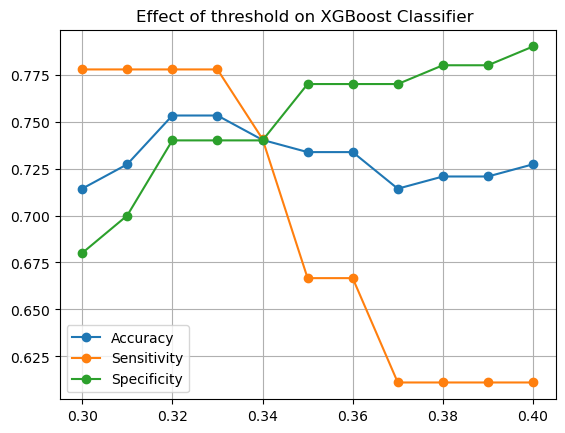

In [160]:
#threshold tuning
y_prob_xgb = xgb_pipe.predict_proba(X_test)[:,1]
thresholds = [0.3,0.31,0.32,0.33,0.34,0.35,0.36,0.37,0.38,0.39,0.4]
results_xgb = []

for thr in thresholds:
    y_pred_xgb = (y_prob_xgb >= thr).astype(int)
    cm = confusion_matrix(y_test,y_pred_xgb)
    tn,fp,fn,tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    results_xgb.append(
        {'threshold':thr,
        'accuracy' : accuracy_score(y_test,y_pred_xgb),
        'balanced_accuracy ':balanced_accuracy_score(y_test,y_pred_xgb),
        'sensitivity':sensitivity,
        'specificity':specificity,
        'tn':tn,
        'fp':fp,
        'fn':fn,
        'tp':tp}
    )

thresholds_df_xgb = pd.DataFrame(results_xgb)
#print(thresholds_df_gb.head())
#plotting
import matplotlib.pyplot as plt

plt.plot(thresholds_df_xgb['threshold'],thresholds_df_xgb['accuracy'],marker = 'o',label = 'Accuracy')
#plt.plot(thresholds_df_gb['threshold'],thresholds_df_gb['balanced_accuracy'],marker = 'o',label = 'Balanced accuracy')
plt.plot(thresholds_df_xgb['threshold'],thresholds_df_xgb['sensitivity'],marker = 'o',label = 'Sensitivity')
plt.plot(thresholds_df_xgb['threshold'],thresholds_df_xgb['specificity'],marker = 'o',label = 'Specificity')
plt.title('Effect of threshold on XGBoost Classifier ')
plt.grid(True)
plt.legend()
plt.show()

In [162]:
#threshold = 0.34
y_prob_xgb = xgb_pipe.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb >= 0.34).astype(int)

print('Evaluation metrics - XGBoost - Threshold = 0.34')
print('Accuracy :',accuracy_score(y_test,y_pred_xgb))
print('Balanced accuracy :',balanced_accuracy_score(y_test,y_pred_xgb))
cm_xgb = confusion_matrix(y_test,y_pred_xgb)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()
sensitivity_xgb = tp_xgb / (tp_xgb + fn_xgb)
specificity_xgb = tn_xgb / (tn_xgb + fp_xgb)
print('Sensitivity :',sensitivity_xgb)
print('Specificity :',specificity_xgb)
print('f1 score :',f1_score(y_test,y_pred_xgb))
print('Confusion Matrix \n')
print(confusion_matrix(y_test,y_pred_xgb))

Evaluation metrics - XGBoost - Threshold = 0.34
Accuracy : 0.7402597402597403
Balanced accuracy : 0.7403703703703703
Sensitivity : 0.7407407407407407
Specificity : 0.74
f1 score : 0.6666666666666666
Confusion Matrix 

[[74 26]
 [14 40]]


In [180]:
#svm
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, StratifiedKFold
svm_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler',StandardScaler()),
    ('model',SVC(kernel = 'rbf',C = 0.6
                 , gamma = 'scale',class_weight = class_weight_dict,probability = True, random_state = 42))
])

svm_pipe.fit(X_train,y_train)

y_pred_train_svm = svm_pipe.predict(X_train)
y_pred_test_svm = svm_pipe.predict(X_test)

print('Overfit check')
print('Training accuracy :',accuracy_score(y_train,y_pred_train_svm))
print('Testing accuracy :',accuracy_score(y_test,y_pred_test_svm))

print('Accuracy :',accuracy_score(y_test,y_pred_test_svm))
print('Balanced accuracy :',balanced_accuracy_score(y_test,y_pred_test_svm))
cm_svm = confusion_matrix(y_test,y_pred_test_svm)
tn_svm,fp_svm,fn_svm,tp_svm = cm_svm.ravel()
sensitivity_svm = tp_svm / (tp_svm + fn_svm)
specificity_svm = tn_svm / (tn_svm + fp_svm)
print('Sensitivity :',sensitivity_svm)
print('Specificity :',specificity_svm)
print('f1 score :',f1_score(y_test,y_pred_test_svm))
print('Confusion Matrix \n')
print(confusion_matrix(y_test,y_pred_test_svm))

print('Cross validation check')
cv = StratifiedKFold(n_splits = 5, shuffle = True)
cv_scores = cross_validate(svm_pipe, X_train,y_train, scoring = 'accuracy',cv = cv,return_train_score = True)
print(cv_scores)
print('Standard deviation of scores :',np.std(cv_scores['test_score']))

Overfit check
Training accuracy : 0.7866449511400652
Testing accuracy : 0.7467532467532467
Accuracy : 0.7467532467532467
Balanced accuracy : 0.7538888888888888
Sensitivity : 0.7777777777777778
Specificity : 0.73
f1 score : 0.6829268292682927
Confusion Matrix 

[[73 27]
 [12 42]]
Cross validation check
{'fit_time': array([0.06856966, 0.06374884, 0.07480431, 0.07350683, 0.07679296]), 'score_time': array([0.00650311, 0.00937867, 0.01177502, 0.01552129, 0.01018214]), 'test_score': array([0.68292683, 0.75609756, 0.71544715, 0.73170732, 0.78688525]), 'train_score': array([0.80040733, 0.79022403, 0.79429735, 0.82077393, 0.7703252 ])}
Standard deviation of scores : 0.03533045973308575


In [218]:
from sklearn.metrics import roc_auc_score

model_cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0
)

param_grid = {
    'iterations': [
        100,200,300,400,500,600
    ],

    'learning_rate': [
        0.005,0.01,0.03,0.05,0.1
    ],

    'depth': [
        3,4,5,6,7,8
    ],

    'l2_leaf_reg': [
        1,3,5,7,9,15
    ],

    'subsample': [
        0.6,0.7,0.8,0.9,1
    ],

    'border_count': [
        32,64,128,256
    ],

    'bagging_temperature': [
        0,0.2,0.5,1,1.2,1.5
    ]
}

random_search = RandomizedSearchCV(
    estimator=model_cat,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

model_cat_best = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest CV ROC AUC:")
print(random_search.best_score_)

y_pred_train_cathyper = model_cat_best.predict(X_train)
y_pred_test_cathyper = model_cat_best.predict(X_test)
y_prob_test_cathyper = model_cat_best.predict_proba(X_test)[:,1]

print('\nOverfit check - Hyperparameter tuning')
print('Training accuracy :',accuracy_score(y_train,y_pred_train_cathyper))
print('Testing accuracy :',accuracy_score(y_test,y_pred_test_cathyper))

print('Evaluation metrics - CatBoost - Hyperparameter tuning')
print('Accuracy :',accuracy_score(y_test,y_pred_test_cathyper))
print('Balanced accuracy :',balanced_accuracy_score(y_test,y_pred_test_cathyper))
cm_cathyper = confusion_matrix(y_test,y_pred_test_cathyper)
tn_cathyper,fp_cathyper,fn_cathyper,tp_cathyper = cm_cathyper.ravel()
sensitivity_cathyper = tp_cathyper / (tp_cathyper + fn_cathyper)
specificity_cathyper = tn_cathyper / (tn_cathyper + fp_cathyper)
print('Sensitivity :',sensitivity_cathyper)
print('Specificity :',specificity_cathyper)
print('f1 score :',f1_score(y_test,y_pred_test_cathyper))
print('ROC AUC Score :',roc_auc_score(y_test,y_pred_test_cathyper))
print('Confusion Matrix\n')
print(confusion_matrix(y_test,y_pred_test_cathyper))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'subsample': 0.6, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 3, 'border_count': 256, 'bagging_temperature': 0.5}

Best CV ROC AUC:
0.8402906976744186

Overfit check - Hyperparameter tuning
Training accuracy : 0.8175895765472313
Testing accuracy : 0.7532467532467533
Evaluation metrics - CatBoost - Hyperparameter tuning
Accuracy : 0.7532467532467533
Balanced accuracy : 0.7546296296296297
Sensitivity : 0.7592592592592593
Specificity : 0.75
f1 score : 0.6833333333333333
ROC AUC Score : 0.7546296296296297
Confusion Matrix

[[75 25]
 [13 41]]


In [222]:
#let's deploy this catboost model
import joblib
joblib.dump(model_cat_best,'catboost_diabetes.pkl')

['catboost_diabetes.pkl']